# ReMA Experiment Analysis

Analysis of autonomous RL experiment results from `results.tsv`.

**Primary metric**: `acc_final` (F1 over QA pairs, higher = better, target > 0.50 at 32 sessions)  
**Health metric**: `mem_fail_final` (memory failure rate, lower = better, must stay < 0.25)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv("results.tsv", sep="\t")
df["val_acc_mid"]      = pd.to_numeric(df["val_acc_mid"],      errors="coerce")
df["mfail_final"] = pd.to_numeric(df["mfail_final"], errors="coerce")
df["val_acc_final"]      = pd.to_numeric(df["val_acc_final"],      errors="coerce")
df["status"]         = df["status"].str.strip().str.lower()

# Exclude still-running entries from analysis
completed = df[~df["status"].isin(["running"])].copy().reset_index(drop=True)

print(f"Total experiments: {len(df)}  (completed: {len(completed)}, running: {(df['status']=='running').sum()})")
print(f"Columns: {list(df.columns)}")
df

Total experiments: 118  (completed: 118, running: 0)
Columns: ['commit', 'start_model', 'val_acc_mid', 'val_acc_final', 'mfail_final', 'status', 'description']


,commit,start_model,val_acc_mid,val_acc_final,mfail_final,status,description
0,014f6ed,base_qwen,0.000,0.403,0.268,keep,"kl001_inner50: baseline, kl=0.001, inner=0.5, ..."
1,014f6ed,base_qwen,0.475,0.496,0.022,keep,"2conv: NUM_TRAIN_CONVS=2, rollouts=8, kl=0.001..."
2,014f6ed,base_qwen,0.439,0.505,0.059,keep,"turns6: max_turns=6, kl=0.001, inner=0.5, 1c×1..."
3,014f6ed,base_qwen,0.441,0.455,0.198,partial,"inner_n8: inner_n=8, kl=0.001, inner=0.5, 1c×1..."
4,014f6ed,base_qwen,0.481,0.469,0.035,keep,"kl0005_inner50_rerun: kl=0.0005, inner=0.5, 1c..."
...,...,...,...,...,...,...,...
113,0127e54,ckpt:8sess_grpo_persession_job3959719_step10,0.000,0.488,0.000,keep,DONE: TEST (OpenOSS): `test_8sess_gae_klsplit_...
114,0127e54,ckpt:8sess_grpo_persession_job3959719_step10,0.000,0.444,0.000,keep,DONE: TEST (Qwen judge): `qwen_judge_test_8ses...
115,0127e54,base_qwen,0.000,0.206,0.252,discard,STOPPED (2026-04-08 15:22 CEST): 8sess_gae_kls...
116,0127e54,ckpt:32sess_cont_comp02_lr1e6_20260408_step5,0.000,0.000,0.000,partial,INVALID (2026-04-08): all OpenOSS eval attempt...


In [23]:
counts = completed["status"].value_counts()
print("Experiment outcomes (completed only):")
print(counts.to_string())

n_keep    = counts.get("keep", 0)
n_discard = counts.get("discard", 0)
n_crash   = counts.get("crash", 0)
n_decided = n_keep + n_discard
print(f"\nKeep rate:   {n_keep}/{n_decided} = {n_keep/n_decided:.1%}" if n_decided else "")
print(f"Crash rate:  {n_crash}/{len(completed)} = {n_crash/len(completed):.1%}")

Experiment outcomes (completed only):
status
keep       84
discard    19
partial    15

Keep rate:   84/103 = 81.6%
Crash rate:  0/118 = 0.0%


In [24]:
kept = completed[completed["status"] == "keep"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
print(f"{'#':>3}  {'acc_final':>9}  {'mfail':>7}  description")
print("-" * 90)
for i, row in kept.iterrows():
    print(f"{i:3d}  {row['val_acc_final']:9.3f}  {row['mfail_final']:7.3f}  {row['description'][:75]}")

KEPT experiments (84 total):

  #  acc_final    mfail  description
------------------------------------------------------------------------------------------
  0      0.403    0.268  kl001_inner50: baseline, kl=0.001, inner=0.5, 1c×16r, 4turns, 8sess, 10step
  1      0.496    0.022  2conv: NUM_TRAIN_CONVS=2, rollouts=8, kl=0.001, inner=0.5, 4turns, 8sess, 1
  2      0.505    0.059  turns6: max_turns=6, kl=0.001, inner=0.5, 1c×16r, 8sess, 10steps (job 39362
  4      0.469    0.035  kl0005_inner50_rerun: kl=0.0005, inner=0.5, 1c×16r, 8sess, 10steps (job 393
  5      0.487    0.034  clip01: clip_ratio=0.1, kl=0.001, inner=0.5, 1c×16r, 4turns, 8sess, 10steps
  6      0.488    0.050  inner_n8_rerun: inner_n=8, kl=0.001, inner=0.5, 1c×16r, 4turns, 8sess, 10st
  7      0.464    0.037  token_agg_traj_rerun: clip_mode=token, agg_mode=trajectory (paper ablation)
  8      0.496    0.061  16sess_kl001: from n8rerun ckpt (val=0.488), kl=0.001, 4turns, 16sess, 5ste
  9      0.399    0.216  16sess_2c

## Accuracy & Memory Failure Over Experiments

Each dot is one completed experiment. Green = kept improvement, grey = discarded, red = crash.  
The stepped line tracks the running best `acc_final` across kept experiments.  
The danger zone (mfail > 0.25) is shaded in the lower panel.

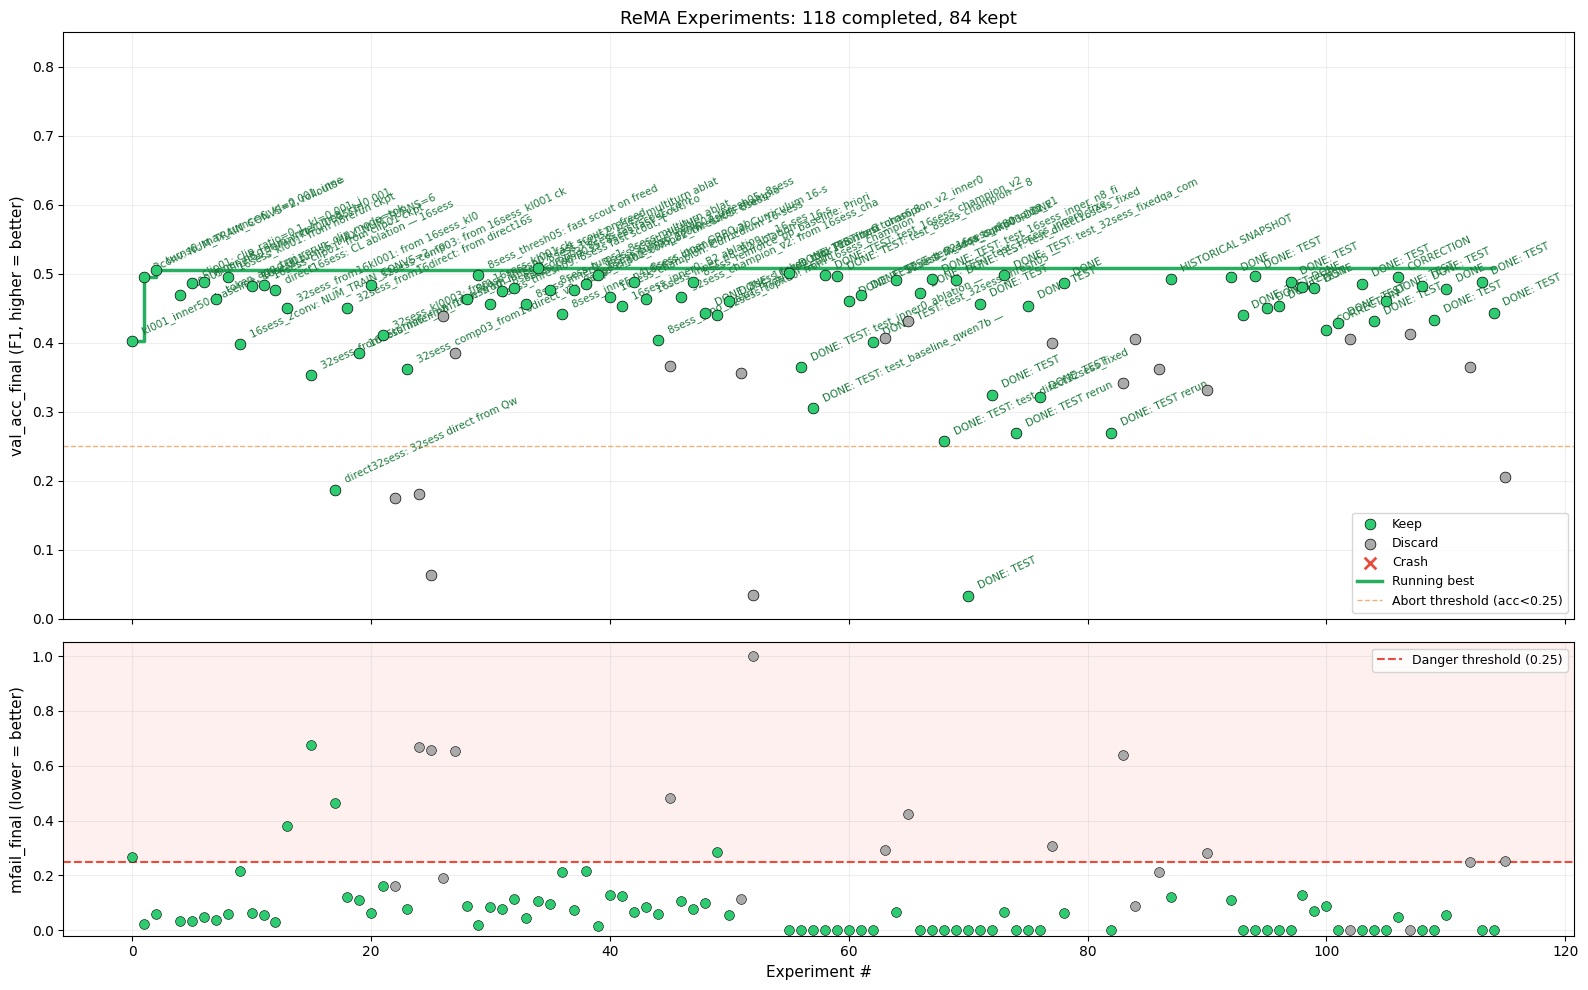

Saved to progress.png


In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

non_crash = completed[completed["status"] != "crash"].copy()
xs = non_crash.index.tolist()

color_map = {"keep": "#2ecc71", "discard": "#aaaaaa"}

# --- Top panel: acc_final ---
for status, color in color_map.items():
    sub = non_crash[non_crash["status"] == status]
    ax1.scatter(sub.index, sub["val_acc_final"], c=color, s=60, zorder=4,
                edgecolors="black", linewidths=0.5, label=status.capitalize())

# Crashes as X marks
crashes = completed[completed["status"] == "crash"]
ax1.scatter(crashes.index, crashes["val_acc_mid"].clip(lower=0.0), marker="x",
            c="#e74c3c", s=70, linewidths=2, zorder=4, label="Crash")

# Running max of kept experiments
kept_mask = non_crash["status"] == "keep"
kept_sub  = non_crash[kept_mask]
if not kept_sub.empty:
    running_best = kept_sub["val_acc_final"].cummax()
    ax1.step(kept_sub.index, running_best, where="post",
             color="#27ae60", linewidth=2.5, zorder=3, label="Running best")
    # Annotate each kept point
    for idx, row in kept_sub.iterrows():
        desc = str(row["description"]).split("(")[0].strip()[:35]
        ax1.annotate(desc, (idx, row["val_acc_final"]),
                     textcoords="offset points", xytext=(6, 5),
                     fontsize=7.5, color="#1a7a3a", rotation=25, ha="left")

ax1.axhline(0.25, color="#e67e22", linestyle="--", linewidth=1, alpha=0.6, label="Abort threshold (acc<0.25)")
ax1.set_ylabel("val_acc_final (F1, higher = better)", fontsize=11)
ax1.set_title(f"ReMA Experiments: {len(completed)} completed, {kept_mask.sum()} kept", fontsize=13)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.set_ylim(0, 0.85)

# --- Bottom panel: mem_fail_final ---
for status, color in color_map.items():
    sub = non_crash[non_crash["status"] == status]
    ax2.scatter(sub.index, sub["mfail_final"], c=color, s=50, zorder=4,
                edgecolors="black", linewidths=0.4)

ax2.scatter(crashes.index, [1.0] * len(crashes), marker="x",
            c="#e74c3c", s=70, linewidths=2, zorder=4)

# Danger zone
ax2.axhspan(0.25, 1.05, color="#e74c3c", alpha=0.08)
ax2.axhline(0.25, color="#e74c3c", linestyle="--", linewidth=1.5, label="Danger threshold (0.25)")
ax2.set_ylabel("mfail_final (lower = better)", fontsize=11)
ax2.set_xlabel("Experiment #", fontsize=11)
ax2.set_ylim(-0.02, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [26]:
kept = completed[completed["status"] == "keep"].copy()

baseline_acc = completed.iloc[0]["val_acc_final"]
best_acc     = kept["val_acc_final"].max()
best_row     = kept.loc[kept["val_acc_final"].idxmax()]

print(f"Baseline acc:      {baseline_acc:.3f}  ({completed.iloc[0]['description'][:60]})")
print(f"Best acc:          {best_acc:.3f}  ({best_row['description'][:60]})")
print(f"Total improvement: +{best_acc - baseline_acc:.3f}  (+{(best_acc - baseline_acc) / baseline_acc * 100:.1f}%)")
print(f"\nStep-by-step improvement chain (KEEP only):")
print(f"{'#':>3}  {'acc':>6}  {'mfail':>6}  {'delta_acc':>9}  description")
print("-" * 95)
prev_acc = None
for i, (_, row) in enumerate(kept.reset_index().iterrows()):
    delta = f"{row['val_acc_final'] - prev_acc:+.3f}" if prev_acc is not None else "  base"
    print(f"{row['index']:3d}  {row['val_acc_final']:6.3f}  {row['mfail_final']:6.3f}  {delta:>9}  {row['description'][:65]}")
    prev_acc = row["val_acc_final"]

Baseline acc:      0.403  (kl001_inner50: baseline, kl=0.001, inner=0.5, 1c×16r, 4turns)
Best acc:          0.509  (8sess_turns2: 8sess multiturn ablation, max_turns=2, RUN_TAG)
Total improvement: +0.106  (+26.3%)

Step-by-step improvement chain (KEEP only):
  #     acc   mfail  delta_acc  description
-----------------------------------------------------------------------------------------------
  0   0.403   0.268       base  kl001_inner50: baseline, kl=0.001, inner=0.5, 1c×16r, 4turns, 8se
  1   0.496   0.022     +0.093  2conv: NUM_TRAIN_CONVS=2, rollouts=8, kl=0.001, inner=0.5, 4turns
  2   0.505   0.059     +0.009  turns6: max_turns=6, kl=0.001, inner=0.5, 1c×16r, 8sess, 10steps 
  4   0.469   0.035     -0.036  kl0005_inner50_rerun: kl=0.0005, inner=0.5, 1c×16r, 8sess, 10step
  5   0.487   0.034     +0.018  clip01: clip_ratio=0.1, kl=0.001, inner=0.5, 1c×16r, 4turns, 8ses
  6   0.488   0.050     +0.001  inner_n8_rerun: inner_n=8, kl=0.001, inner=0.5, 1c×16r, 4turns, 8
  7   0.464  

## Acc vs Mem-Fail Scatter (Health Map)

Each completed experiment as a point. The green zone (top-left) is the target: high accuracy AND low memory failure rate. The red zone (right of x=0.25) signals instability.

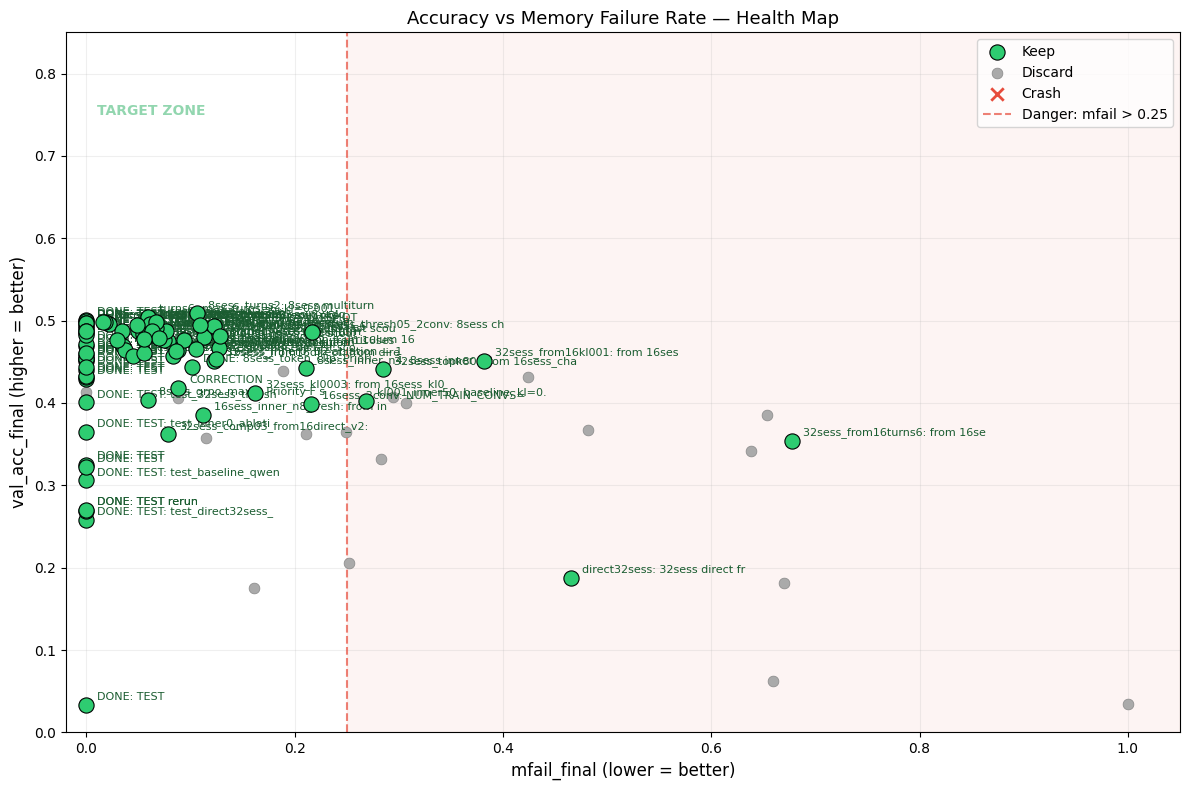

Saved to health_map.png


In [27]:
fig, ax = plt.subplots(figsize=(12, 8))

status_styles = {
    "keep":    dict(color="#2ecc71", marker="o", s=120, zorder=5, edgecolors="black", linewidths=0.8),
    "discard": dict(color="#aaaaaa", marker="o", s=60,  zorder=3, edgecolors="#888888", linewidths=0.5),
    "crash":   dict(color="#e74c3c", marker="x", s=80,  zorder=4, linewidths=2),
}

for status, style in status_styles.items():
    sub = completed[completed["status"] == status]
    ax.scatter(sub["mfail_final"], sub["val_acc_final"], label=status.capitalize(), **style)

# Danger zone shading
ax.axvspan(0.25, 1.05, color="#e74c3c", alpha=0.06)
ax.axvline(0.25, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.7, label="Danger: mfail > 0.25")

# Label kept experiments
kept = completed[completed["status"] == "keep"]
for _, row in kept.iterrows():
    desc = str(row["description"]).split("(")[0].strip()[:30]
    ax.annotate(desc, (row["mfail_final"], row["val_acc_final"]),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8, color="#1a5c30")

ax.set_xlabel("mfail_final (lower = better)", fontsize=12)
ax.set_ylabel("val_acc_final (higher = better)", fontsize=12)
ax.set_title("Accuracy vs Memory Failure Rate — Health Map", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(0, 0.85)

# Target region annotation
ax.annotate("TARGET ZONE", xy=(0.01, 0.75), fontsize=10,
            color="#27ae60", fontweight="bold", alpha=0.5)

plt.tight_layout()
plt.savefig("health_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to health_map.png")

## Step-5 Early Signal vs Final Result

How well does `acc_step5` predict `acc_final`? This determines whether 5-step scouts are a reliable proxy for full runs.

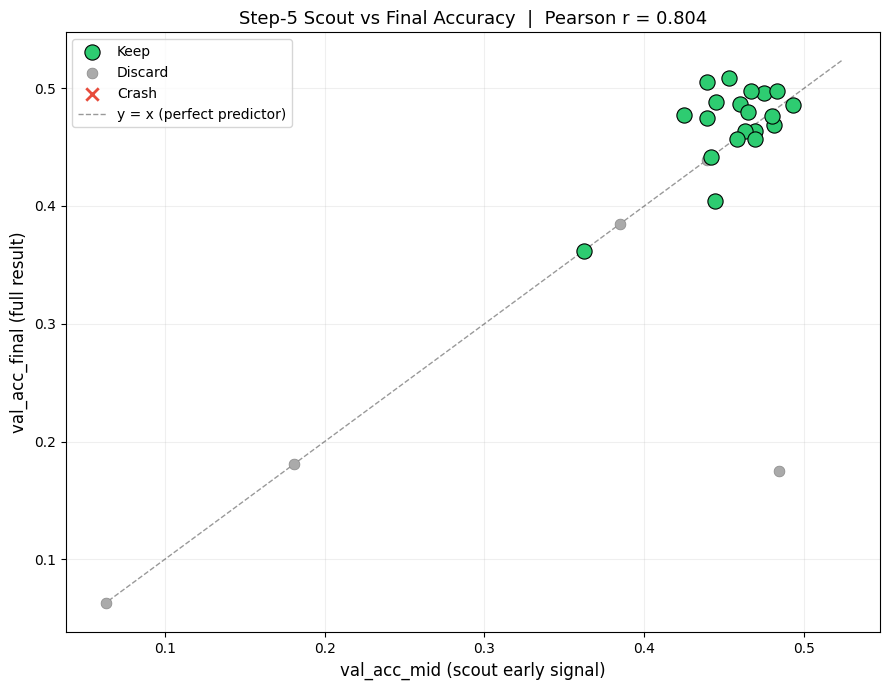

Pearson r = 0.804  (n=26 experiments)

Mean |error| = 0.029
Bias (final - step5) = -0.001


In [28]:
valid = completed[(completed["val_acc_mid"] > 0) & (completed["val_acc_final"] > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 7))

for status, style in status_styles.items():
    sub = valid[valid["status"] == status]
    ax.scatter(sub["val_acc_mid"], sub["val_acc_final"], label=status.capitalize(), **style)

# Identity line (perfect predictor)
lims = [valid["val_acc_mid"].min() * 0.97, valid["val_acc_final"].max() * 1.03]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.4, label="y = x (perfect predictor)")

# Correlation
corr = valid[["val_acc_mid","val_acc_final"]].corr().iloc[0,1]
ax.set_xlabel("val_acc_mid (scout early signal)", fontsize=12)
ax.set_ylabel("val_acc_final (full result)", fontsize=12)
ax.set_title(f"Step-5 Scout vs Final Accuracy  |  Pearson r = {corr:.3f}", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("step5_vs_final.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Pearson r = {corr:.3f}  (n={len(valid)} experiments)")
print(f"\nMean |error| = {(valid['val_acc_final'] - valid['val_acc_mid']).abs().mean():.3f}")
print(f"Bias (final - step5) = {(valid['val_acc_final'] - valid['val_acc_mid']).mean():+.3f}")